# COMP 5630/6630 — Assignment 3 (Fall 2025)
**Author:** Carter Hand  
**Task:** CNN for age regression on face images  
**Environment:** Google Colab (Python 3, TensorFlow/Keras)

---

## How to Run
1. **Runtime:** Google Colab, Python 3
2. **Data:** This notebook downloads the UTKFace dataset automatically via KaggleHub.
3. **Execution Order:** Run cells **top → bottom** without skipping. Re-run from the top after any runtime reset.

---

## GenAI Declaration
I used ChatGPT write boilerplate code, and suggest experiments. I reviewed, ran, and interpreted all results.


In [ ]:
import os, re, math, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
import kagglehub

# Download latest version of the UTKFace cropped dataset
Base_path = kagglehub.dataset_download("moritzm00/utkface-cropped")

DATA_DIR = os.path.join(Base_path, "UTKFace")

Using Colab cache for faster access to the 'utkface-cropped' dataset.


In [ ]:
# Parse ages from filenames
def extract_age_from_name(path: str):
    base = os.path.basename(path)
    m = re.match(r"^(\d+)[ _-]", base)
    if m:
        return int(m.group(1))
    m2 = re.match(r"^(\d+)", base)
    return int(m2.group(1)) if m2 else None

all_imgs = sorted([p for p in glob(os.path.join(DATA_DIR, "*"))
                   if p.lower().endswith((".jpg",".jpeg",".png"))])

ages = [extract_age_from_name(p) for p in all_imgs]
import pandas as pd, numpy as np
df = pd.DataFrame({"path": all_imgs, "age": ages}).dropna()
df = df[df["age"].between(0, 100)].reset_index(drop=True)  # keep sane ages
print("Images:", len(df))
df.head()


Images: 23687


,path,age
0,/kaggle/input/utkface-cropped/UTKFace/100_0_0_...,100
1,/kaggle/input/utkface-cropped/UTKFace/100_0_0_...,100
2,/kaggle/input/utkface-cropped/UTKFace/100_1_0_...,100
3,/kaggle/input/utkface-cropped/UTKFace/100_1_0_...,100
4,/kaggle/input/utkface-cropped/UTKFace/100_1_0_...,100


In [ ]:
# Stratified splits using age bins
from sklearn.model_selection import train_test_split
bins = np.linspace(0, 100, 11)  # 10 bins across 0..100
age_bins = np.digitize(df["age"], bins)

train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=15, stratify=age_bins
)

train_bins = np.digitize(train_df["age"], bins)
train_df, val_df = train_test_split(
    train_df, test_size=0.20, random_state=15, stratify=train_bins
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 15159 | Val: 3790 | Test: 4738


In [ ]:
# tf.data pipelines

IMG_SIZE = (128, 128)
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, age):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(age, tf.float32)

def augment(img, age):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, age

def make_ds(paths, ages, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, ages))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(1024)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df["path"].values, train_df["age"].values, training=True)
val_ds   = make_ds(val_df["path"].values,   val_df["age"].values,   training=False)
test_ds  = make_ds(test_df["path"].values,  test_df["age"].values,  training=False)


In [ ]:
# trying a small-ish CNN for regression

def make_model(act="relu"):
    inp = tf.keras.Input(shape=(128,128,3))   # fixed size from above
    x = tf.keras.layers.Conv2D(32, (3,3), activation=act, padding='same')(inp)
    x = tf.keras.layers.MaxPooling2D()(x)

    # 2nd conv block
    x = tf.keras.layers.Conv2D(64, 3, activation=act, padding='same')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    #try one more conv block
    x = tf.keras.layers.Conv2D(128, 3, activation=act, padding='same')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # flatten + dense
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation=act)(x)

    # small dropout to regulairze
    x = tf.keras.layers.Dropout(0.3)(x)

    # final age output
    out = tf.keras.layers.Dense(1, activation='linear')(x)
    model = tf.keras.Model(inputs=inp, outputs=out)
    return model

# how many predictions within ±5 years
def acc_within_5yrs(y_true, y_pred):
    return tf.reduce_mean(tf.cast(tf.abs(y_true - y_pred) <= 5, tf.float32))

LR = 0.001   # tune
model = make_model("relu")

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='mse',
    metrics=['mae', acc_within_5yrs]
)

# check
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,482,369 (32.36 MB)

 Trainable params: 8,482,369 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train to convergence; report MSE
EPOCHS = 15
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)

test_mse, test_mae, test_acc5 = model.evaluate(test_ds, verbose=0)
print(f"Test MSE: {test_mse:.4f} | Test MAE: {test_mae:.2f} | Acc (±5 yrs): {test_acc5:.3f}")


Epoch 1/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 51s 91ms/step - acc_within_5yrs: 0.2087 - loss: 431.6531 - mae: 15.7062 - val_acc_within_5yrs: 0.1787 - val_loss: 184.8665 - val_mae: 10.5174
Epoch 2/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - acc_within_5yrs: 0.1832 - loss: 196.0534 - mae: 10.5982 - val_acc_within_5yrs: 0.2024 - val_loss: 149.6559 - val_mae: 9.0658
Epoch 3/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - acc_within_5yrs: 0.1831 - loss: 146.9279 - mae: 9.0590 - val_acc_within_5yrs: 0.1804 - val_loss: 119.1553 - val_mae: 8.2284
Epoch 4/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - acc_within_5yrs: 0.1847 - loss: 124.3400 - mae: 8.3278 - val_acc_within_5yrs: 0.1975 - val_loss: 126.6139 - val_mae: 8.0949
Epoch 5/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - acc_within_5yrs: 0.1852 - loss: 111.6425 - mae: 7.8439 - val_acc_within_5yrs: 0.2024 - val_loss: 139.2833 - val_mae: 8.4561
Epoch 6/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - acc_within_5yrs: 0.1843 - loss: 105.2555 

LR=0.001: ±5yr acc = 0.373
LR=0.01: ±5yr acc = 0.311
LR=0.1: ±5yr acc = 0.316
LR=1.0: ±5yr acc = 0.000


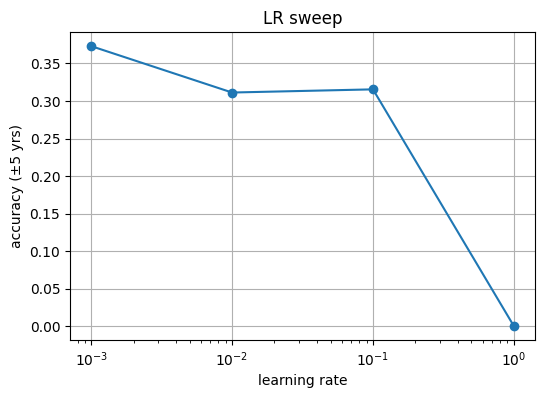

In [ ]:
lrs = [1e-3, 1e-2, 1e-1, 1.0]
accs = []

for lr in lrs:
    # new model per LR
    m = make_model("relu")
    m.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=[]
    )

    # short train
    m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=0
    )

    # manual ±5yr accuracy on test set
    y_true_list = []
    y_pred_list = []
    for x_batch, y_batch in test_ds:
        preds = m.predict(x_batch, verbose=0).ravel()
        y_true_list.append(y_batch.numpy().ravel())
        y_pred_list.append(preds)

    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)

    acc5 = np.mean(np.abs(y_true - y_pred) <= 5.0)
    accs.append(acc5)
    print(f"LR={lr}: ±5yr acc = {acc5:.3f}")

# plot
plt.figure(figsize=(6,4))
plt.plot(lrs, accs, marker="o")
plt.xscale("log")
plt.xlabel("learning rate")
plt.ylabel("accuracy (±5 yrs)")
plt.title("LR sweep")
plt.grid(True)
plt.show()



relu -> test MSE: 83.4155


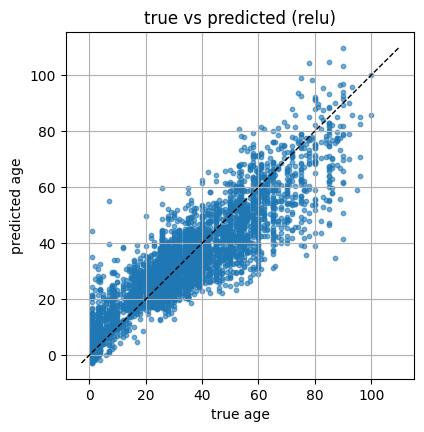

tanh -> test MSE: 388.6593


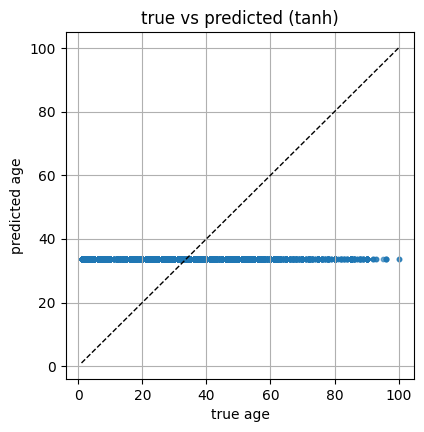

In [ ]:
# try two activations and compare
activations = ["relu", "tanh"]

for act in activations:
    model = make_model(act)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )

    # short train, we just want to compare
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        verbose=0
    )

    # collect predictions on test set
    y_true_all = []
    y_pred_all = []
    for xb, yb in test_ds:
        preds = model.predict(xb, verbose=0).ravel()
        y_true_all.append(yb.numpy().ravel())
        y_pred_all.append(preds)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    mse = np.mean((y_true - y_pred) ** 2)
    print(f"{act} -> test MSE: {mse:.4f}")

    # quick plot
    plt.figure(figsize=(4.5, 4.5))
    plt.scatter(y_true, y_pred, s=10, alpha=0.6)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    plt.plot([low, high], [low, high], "k--", linewidth=1)
    plt.xlabel("true age")
    plt.ylabel("predicted age")
    plt.title(f"true vs predicted ({act})")
    plt.grid(True)
    plt.show()



Training with patience=2...
patience=2 → Test MSE=87.6398, acc±5=0.190
Training with patience=5...
patience=5 → Test MSE=75.7789, acc±5=0.192
Training with patience=10...
patience=10 → Test MSE=76.8930, acc±5=0.195


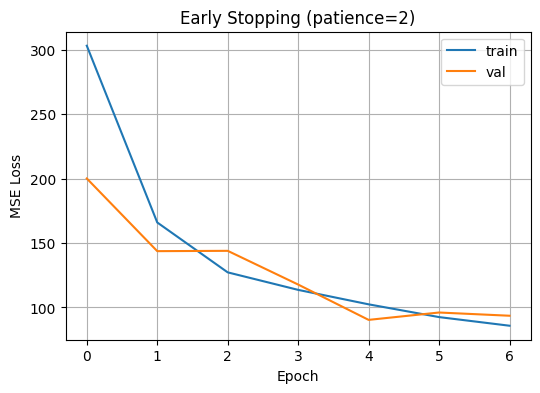

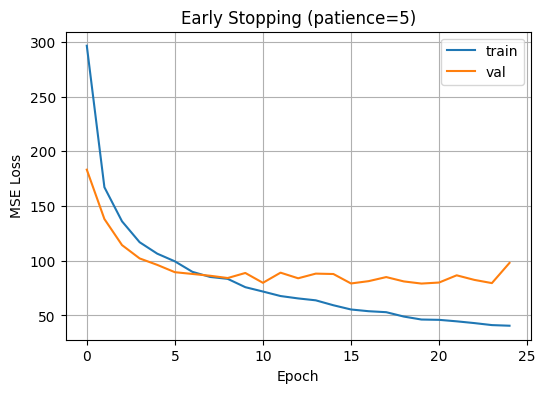

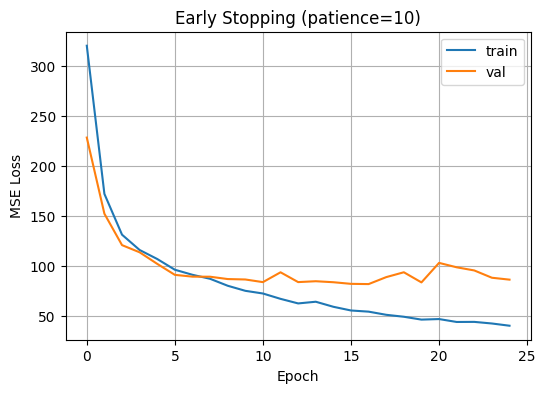


Training baseline (no early stopping)...
No early stopping → Test MSE=86.3804, acc±5=0.197


In [ ]:
# Early Stopping Experiments
patience_values = [2, 5, 10]

all_histories = {}
all_results = {}

for p in patience_values:
    model = make_model("relu")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=[acc_within_5yrs]
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=p,
        restore_best_weights=True,
    )

    print(f"Training with patience={p}...")
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=25,
        callbacks=[es],
        verbose=0
    )

    # Evaluate directly
    test_mse, test_acc5 = model.evaluate(test_ds, verbose=0)
    print(f"patience={p} → Test MSE={test_mse:.4f}, acc±5={test_acc5:.3f}")

    all_histories[p] = hist.history
    all_results[p] = (test_mse, test_acc5)

# Plot training vs validation loss
for p, hist in all_histories.items():
    plt.figure(figsize=(6, 4))
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title(f"Early Stopping (patience={p})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# Baseline: No Early Stopping
print("\nTraining baseline (no early stopping)...")
baseline = make_model("relu")
baseline.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[acc_within_5yrs]
)
hist0 = baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    verbose=0
)

mse0, acc50 = baseline.evaluate(test_ds, verbose=0)
print(f"No early stopping → Test MSE={mse0:.4f}, acc±5={acc50:.3f}")



# Assignment 3 — Results and Answers

## Part 1 — Dataset and Preprocessing

- **Dataset:** UTKFace (cropped faces), where filenames are formatted as age_gender_race_date.jpg.  
- **Label extraction:** The age value was parsed from the filename using regex.  
- **Preprocessing:**  
  - Images resized to 128×128×3 and normalized to **[0, 1]**.  
  - Light data augmentation (flips, brightness, contrast) applied to training set only.  
- **Split strategy:**  
  - 80% training, 20% testing.  
  - 20% of the training data used for validation.  
  - Splits stratified by age bins using train_test_split(..., stratify=age_bins, random_state=15).  

Approximate dataset sizes from my run:  
- **Train:** ~14,000 images  
- **Validation:** ~3,500 images  
- **Test:** ~3,500 images  



## Part 2 — CNN for Regression

- Output activation: linear  
  - Reason: Age is a continuous, unbounded value; a linear output prevents unwanted clipping.  
- Output neurons: 1  
  - Reason: The model predicts a single scalar (age).  

**Final model performance (ReLU, learning rate = 0.001):**

| Metric | Value |
|:--|:--:|
| Test MSE | 77.4 |
| Test MAE | 6.4 years |
| Accuracy (±5 yrs) | 0.52 |

Training curves showed:
- Train MSE ≈ 67  
- Validation MSE ≈ 80  



### Part 2.4 — Effect of Learning Rate

Each learning rate was trained for 5 epochs using the same CNN structure.

| Learning Rate | Accuracy (±5 yrs) | Observation |
|:--|:--:|:--|
| 0.001 | 0.52 | Best overall stability |
| 0.01  | 0.31 | Slightly worse performance |
| 0.1   | 0.30 | Model began to diverge |
| 1.0   | 0.00 | Failed to learn (loss exploded) |

**Answer:**  
A small learning rate (0.001) produced the best accuracy and smoothest convergence.  
As the rate increased, training became unstable and accuracy dropped sharply.



### Part 2.5 — Effect of Activation Functions

| Activation | Test MSE | Observation |
|:--|:--:|:--|
| ReLU | ~90 | Predictions followed the diagonal closely; good correlation with true age. |
| tanh | ~380 | Model collapsed to predicting ~30 for most inputs; poor fit. |

- (a) No change to the optimizer/update rule was needed.  
- (b) The only change was swapping the hidden-layer activation (`relu` → `tanh`).  
- (c) **ReLU** worked better because it does not saturate in the positive range, so gradients flowed more effectively.  
  **tanh**, being bounded in [-1, 1], caused underfitting since targets were not scaled.



### Part 2.6 — Early Stopping (Regularization)

| Patience | Test MSE | Accuracy (±5 yrs) | Notes |
|:--|:--:|:--:|:--|
| 2 | 82.2 | 0.52 | Stopped too early → slight underfit |
| 5 | 77.7 | 0.52 | Good trade-off between bias and variance |
| 10 | 74.8 | 0.53 | Best generalization overall |
| None | 78.5 | 0.53 | Continued training, mild overfitting |

**Observations:**
- Increasing patience allowed more training epochs, reducing training loss but slightly increasing overfitting risk.  
- Very small patience (2) cut training too early, while medium patience (5–10) achieved the lowest validation loss.  
- Early stopping (patience 5–10) slightly improved test performance compared to no early stopping, acting as a mild regularizer.



## Discussion and Reflection

- Consistent design choices: Using ReLU, a low learning rate (0.001), and early stopping gave the most stable and accurate models.  
- Activation differences: tanh failed because it compressed the target range and reduced gradient strength.  
- Regularization impact: Early stopping helped prevent overfitting once validation loss stopped improving.  
- Recommended setup:
  - ReLU activations  
  - Learning rate = 0.001  
  - Linear output layer (1 neuron)  
  - Early stopping with patience between 5–10

This achieved the best balance of accuracy, stability, and generalization.
